# 00_라이브러리 + 데이터 로드 (merged_0302)

In [ ]:
import lightgbm as lgb
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')
merged = pd.read_csv("/content/drive/MyDrive/01_project/260226_datathon/preprocessed_merged_reviewed_0302.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(merged.shape)
merged.head()

(213451, 44)


,user_id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_browser,country_destination,is_booked,dac_year,dac_month,dac_dayofweek,dac_is_weekend,tfa_hour,tfa_dayofweek,days_lag,age_missing,cnt_-unknown-,cnt_booking_request,cnt_booking_response,cnt_click,cnt_data,cnt_message_post,cnt_modify,cnt_partner_callback,cnt_submit,cnt_view,cnt_NaN,sess_event_cnt_sum,sess_secs_nonnull_sum,main_device_type_d,multi_device,sig_action,sig_action_detail,secs_elapsed_sum,secs_median,secs_avr,sig_action_cnt,sig_action_detail_cnt,has_session
0,gxn3p5htnn,unknown,NaN,facebook,0,en,direct,direct,untracked,Web,Chrome,NDF,0,2010,6,0,0,4,3,466,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NO_SESSION,NO_SESSION,0.0,0.0,0.0,0,0,0
1,820tgsjxq7,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Chrome,NDF,0,2011,5,2,0,17,5,732,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NO_SESSION,NO_SESSION,0.0,0.0,0.0,0,0,0
2,4ft3gnwmtx,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,IE,US,1,2010,9,1,0,23,1,476,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NO_SESSION,NO_SESSION,0.0,0.0,0.0,0,0,0
3,bjjt8pjhuk,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Firefox,other,1,2011,12,0,0,6,5,765,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NO_SESSION,NO_SESSION,0.0,0.0,0.0,0,0,0
4,87mebub9p4,unknown,41.0,basic,0,en,direct,direct,untracked,Web,Chrome,US,1,2010,9,1,0,6,1,280,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NO_SESSION,NO_SESSION,0.0,0.0,0.0,0,0,0


In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 44 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  213451 non-null  object 
 1   gender                   213451 non-null  object 
 2   age                      122861 non-null  float64
 3   signup_method            213451 non-null  object 
 4   signup_flow              213451 non-null  object 
 5   language                 213451 non-null  object 
 6   affiliate_channel        213451 non-null  object 
 7   affiliate_provider       213451 non-null  object 
 8   first_affiliate_tracked  213451 non-null  object 
 9   signup_app               213451 non-null  object 
 10  first_browser            213451 non-null  object 
 11  country_destination      213451 non-null  object 
 12  is_booked                213451 non-null  int64  
 13  dac_year                 213451 non-null  int64  
 14  dac_

In [ ]:
merged.describe()

,age,is_booked,dac_year,dac_month,dac_dayofweek,dac_is_weekend,tfa_hour,tfa_dayofweek,days_lag,age_missing,cnt_-unknown-,cnt_booking_request,cnt_booking_response,cnt_click,cnt_data,cnt_message_post,cnt_modify,cnt_partner_callback,cnt_submit,cnt_view,cnt_NaN,sess_event_cnt_sum,sess_secs_nonnull_sum,main_device_type_d,multi_device,secs_elapsed_sum,secs_median,secs_avr,sig_action_cnt,sig_action_detail_cnt,has_session
count,122861.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.0,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,213451.000000,2.134510e+05,2.134510e+05,2.134510e+05,213451.000000,213451.000000,213451.000000
mean,36.463809,0.416527,2013.023846,6.022459,2.764246,0.230057,12.242112,2.764152,0.231819,0.424407,2.646055,0.050105,0.000009,4.986793,5.567999,0.260327,0.0,0.032818,1.674253,7.822512,2.903992,25.944863,25.599046,0.236912,0.093820,5.236483e+05,2.435047e+03,1.111382e+04,0.594483,0.768289,0.345817
std,11.455232,0.492984,0.938489,3.236690,1.944807,0.420870,8.056394,1.944793,11.948395,0.494254,13.198390,0.236087,0.003061,18.639978,18.219450,1.138021,0.0,0.238437,6.400553,26.035814,11.523741,75.189408,74.964844,0.425189,0.291579,1.335854e+06,2.902571e+04,3.847739e+04,2.154198,4.777191,0.475635
min,15.000000,0.000000,2010.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,28.000000,0.000000,2012.000000,3.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
50%,33.000000,0.000000,2013.000000,6.000000,3.000000,0.000000,15.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
75%,42.000000,1.000000,2014.000000,9.000000,4.000000,0.000000,20.000000,4.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.0,0.000000,1.000000,4.000000,0.000000,15.000000,14.000000,0.000000,0.000000,3.060465e+05,8.005000e+02,1.002298e+04,1.000000,1.000000,1.000000
max,90.000000,1.000000,2014.000000,12.000000,6.000000,1.000000,23.000000,6.000000,1456.000000,1.000000,2188.000000,6.000000,1.000000,987.000000,801.000000,69.000000,0.0,18.000000,296.000000,1839.000000,806.000000,2644.000000,2643.000000,1.000000,1.000000,3.822136e+07,1.703242e+06,1.703242e+06,183.000000,807.000000,1.000000


# 01_df_v1
- Baseline 모델
- age_missing, age 컬럼 포함

In [ ]:
##### **1. 데이터 불러오기(위 merged 데이터셋 copy본 사용)**
df_v1 = merged.copy()

# 불필요한 컬럼 제거 (user_id는 나중을 위해 따로 보관)
user_ids_v1 = df_v1['user_id']
cols_to_drop_v1 = ['user_id']
df_model_v1 = df_v1.drop(columns=cols_to_drop_v1)

# LightGBM을 위한 카테고리 변환
cat_cols_v1 = df_model_v1.select_dtypes(include=['object']).columns
for col in cat_cols_v1:
    # country_destination은 정답지이므로 제외하고 나머지 변수들만 변환
    if col not in ['country_destination']:
        df_model_v1[col] = df_model_v1[col].astype('category')

print("최종 모델용 데이터 shape (v1):", df_model_v1.shape)

##### **2. X(특징), y(정답) 분리**

# country_destination은 Step 2용이므로 여기서 뺌.
X_v1 = df_model_v1.drop(columns=['is_booked', 'country_destination'])
y_v1 = df_model_v1['is_booked']
print("X_v1 shape:", X_v1.shape)
print("y_v1 shape:", y_v1.shape)

##### **3. 데이터 쪼개기 (train / es / th / test)**

X_train_v1, X_temp_v1, y_train_v1, y_temp_v1 = train_test_split(
    X_v1, y_v1,
    test_size=0.30,          # 70% train / 30% 나머지
    random_state=42,
    stratify=y_v1
)

X_es_v1, X_holdout_v1, y_es_v1, y_holdout_v1 = train_test_split(
    X_temp_v1, y_temp_v1,
    test_size=0.50,          # 15% es / 15% holdout
    random_state=42,
    stratify=y_temp_v1
)

X_th_v1, X_test_v1, y_th_v1, y_test_v1 = train_test_split(
    X_holdout_v1, y_holdout_v1,
    test_size=0.50,          # 7.5% th / 7.5% test
    random_state=42,
    stratify=y_holdout_v1
)

print("X_train_v1 shape:", X_train_v1.shape)
print("y_train_v1 shape:", y_train_v1.shape)
print("X_es_v1 shape:", X_es_v1.shape)
print("y_es_v1 shape:", y_es_v1.shape)
print("X_th_v1 shape:", X_th_v1.shape)
print("y_th_v1 shape:", y_th_v1.shape)
print("X_test_v1 shape:", X_test_v1.shape)
print("y_test_v1 shape:", y_test_v1.shape)

##### **4. 모델 생성 및 학습 (v1)**

model_step1_v1 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

# early stopping은 X_es_v1, y_es_v1 에만 사용
model_step1_v1.fit(
    X_train_v1, y_train_v1,
    eval_set=[(X_es_v1, y_es_v1)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

##### **5. 결과 저장: 여러 y_prob 세트 (v1)**

# 1) train 세트 예측 확률
y_prob_train_v1 = model_step1_v1.predict_proba(X_train_v1)[:, 1]

# 2) early stopping 세트 예측 확률
y_prob_es_v1 = model_step1_v1.predict_proba(X_es_v1)[:, 1]

# 3) threshold 탐색용 세트 예측 확률
y_prob_th_v1 = model_step1_v1.predict_proba(X_th_v1)[:, 1]

# 4) 최종 test 세트 예측 확률
y_prob_test_v1 = model_step1_v1.predict_proba(X_test_v1)[:, 1]

print("각 세트별 y_prob_v1 shape:")
print("train:", y_prob_train_v1.shape)
print("es   :", y_prob_es_v1.shape)
print("th   :", y_prob_th_v1.shape)
print("test :", y_prob_test_v1.shape)

# 기본 threshold 0.5 기준 test 성능 (baseline)
y_pred_v1_default = (y_prob_test_v1 >= 0.5).astype(int)
roc_auc_v1_default = roc_auc_score(y_test_v1, y_prob_test_v1)
report_v1_default = classification_report(
    y_test_v1, y_pred_v1_default,
    output_dict=True,
    zero_division=0
)
cm_v1_default = confusion_matrix(y_test_v1, y_pred_v1_default)
print(f"[v1] 기본 threshold=0.50 ROC")


최종 모델용 데이터 shape (v1): (213451, 43)
X_v1 shape: (213451, 41)
y_v1 shape: (213451,)
X_train_v1 shape: (149415, 41)
y_train_v1 shape: (149415,)
X_es_v1 shape: (32018, 41)
y_es_v1 shape: (32018,)
X_th_v1 shape: (16009, 41)
y_th_v1 shape: (16009,)
X_test_v1 shape: (16009, 41)
y_test_v1 shape: (16009,)
[LightGBM] [Info] Number of positive: 62235, number of negative: 87180
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3008
[LightGBM] [Info] Number of data points in the train set: 149415, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.416524 -> initscore=-0.337057
[LightGBM] [Info] Start training from score -0.337057
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[378]	valid_0's binary_logloss: 0.546636
각 세트별

# 02_df_v2
 - age 컬럼 제외


In [ ]:
##### **1. 데이터 불러오기(위 merged 데이터셋 copy본 사용)**

df_v2 = merged.copy()

# 불필요한 컬럼 제거 (user_id는 나중을 위해 따로 보관)
user_ids_v2 = df_v2['user_id']
cols_to_drop_v2 = ['user_id', 'age'] # age 컬럼 제거
df_model_v2 = df_v2.drop(columns=cols_to_drop_v2)

# LightGBM을 위한 카테고리 변환
# 문자열(object)로 된 컬럼들만 찾아서 category 타입으로 바꿈.

cat_cols_v2 = df_model_v2.select_dtypes(include=['object']).columns

for col in cat_cols_v2:
    # country_destination은 정답지이므로 제외하고 나머지 변수들만 변환
    if col not in ['country_destination']:
        df_model_v2[col] = df_model_v2[col].astype('category')


print("최종 모델용 데이터 shape:", df_model_v2.shape)




##### **2. X(특징), y(정답) 분리**
# country_destination은 Step 2용이므로 여기서 뺌.
X_v2 = df_model_v2.drop(columns=['is_booked', 'country_destination'])
y_v2 = df_model_v2['is_booked']

print("X shape:", X_v2.shape)
print("y shape:", y_v2.shape)






##### **3. 데이터 쪼개기**
X_train_v2, X_valid_v2, y_train_v2, y_valid_v2 = train_test_split(X_v2, y_v2,
                                                                  test_size=0.2,
                                                                  random_state=42,
                                                                  stratify=y_v2)

print("X_train shape:", X_train_v2.shape)
print("y_train shape:", y_train_v2.shape)
print("X_valid shape:", X_valid_v2.shape)
print("y_valid shape:", y_valid_v2.shape)




##### **4. 모델 생성 및 학습**
# categorical_feature='auto' 옵션 덕분에 별도의 인코딩이 필요 없음.

model_step1_v2 = lgb.LGBMClassifier(n_estimators=1000,
                                    learning_rate=0.05,
                                    random_state=42)

model_step1_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_valid_v2, y_valid_v2)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)




##### **5. 결과 저장**
y_prob_v2 = model_step1_v2.predict_proba(X_valid_v2)[:, 1]
y_pred_v2 = (y_prob_v2 > 0.5).astype(int)


roc_auc_v2 = roc_auc_score(y_valid_v2, y_prob_v2)
report_v2 = classification_report(y_valid_v2, y_pred_v2, output_dict=True, zero_division=0)
cm_v2 = confusion_matrix(y_valid_v2, y_pred_v2)

print(f"최종 ROC-AUC 점수: {roc_auc_v2:.4f}")

최종 모델용 데이터 shape: (213451, 42)
X shape: (213451, 40)
y shape: (213451,)
X_train shape: (170760, 40)
y_train shape: (170760,)
X_valid shape: (42691, 40)
y_valid shape: (42691,)
[LightGBM] [Info] Number of positive: 71126, number of negative: 99634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.095449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2965
[LightGBM] [Info] Number of data points in the train set: 170760, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.416526 -> initscore=-0.337051
[LightGBM] [Info] Start training from score -0.337051
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[284]	valid_0's binary_logloss: 0.548279
최종 ROC-AUC 점수: 0.7836


# 03_df_v3
  - age_missing 컬럼 제외

In [ ]:
##### **1. 데이터 불러오기(위 merged 데이터셋 copy본 사용)**
df_v3 = merged.copy()

# 불필요한 컬럼 제거 (user_id는 나중을 위해 따로 보관)
user_ids_v3 = df_v3['user_id']
cols_to_drop_v3 = ['user_id','age_missing']
df_model_v3 = df_v3.drop(columns=cols_to_drop_v3)

# LightGBM을 위한 카테고리 변환
# 문자열(object)로 된 컬럼들만 찾아서 category 타입으로 바꿈.

cat_cols_v3 = df_model_v3.select_dtypes(include=['object']).columns

for col in cat_cols_v3:
    # country_destination은 정답지이므로 제외하고 나머지 변수들만 변환
    if col not in ['country_destination']:
        df_model_v3[col] = df_model_v3[col].astype('category')

print("최종 모델용 데이터 shape:", df_model_v3.shape)




##### **2. X(특징), y(정답) 분리**
# country_destination은 Step 2용이므로 여기서 뺌.
X_v3 = df_model_v3.drop(columns=['is_booked', 'country_destination'])
y_v3 = df_model_v3['is_booked']

print("X shape:", X_v3.shape)
print("y shape:", y_v3.shape)




##### **3. 데이터 쪼개기**
X_train_v3, X_valid_v3, y_train_v3, y_valid_v3 = train_test_split(X_v3, y_v3,
                                                                  test_size=0.2,
                                                                  random_state=42,
                                                                  stratify=y_v3)

print("X_train shape:", X_train_v3.shape)
print("y_train shape:", y_train_v3.shape)
print("X_valid shape:", X_valid_v3.shape)
print("y_valid shape:", y_valid_v3.shape)





##### **4. 모델 생성 및 학습**
# categorical_feature='auto' 옵션 덕분에 별도의 인코딩이 필요 없음.

model_step1_v3 = lgb.LGBMClassifier(n_estimators=1000,
                                    learning_rate=0.05,
                                    random_state=42)

model_step1_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_valid_v3, y_valid_v3)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)




##### **5. 결과 저장**

y_prob_v3 = model_step1_v3.predict_proba(X_valid_v3)[:, 1]
y_pred_v3 = (y_prob_v3 > 0.5).astype(int)

roc_auc_v3 = roc_auc_score(y_valid_v3, y_prob_v3)
report_v3 = classification_report(y_valid_v3, y_pred_v3, output_dict=True, zero_division=0)
cm_v3 = confusion_matrix(y_valid_v3, y_pred_v3)

print(f"최종 ROC-AUC 점수: {roc_auc_v3:.4f}")


최종 모델용 데이터 shape: (213451, 42)
X shape: (213451, 40)
y shape: (213451,)
X_train shape: (170760, 40)
y_train shape: (170760,)
X_valid shape: (42691, 40)
y_valid shape: (42691,)
[LightGBM] [Info] Number of positive: 71126, number of negative: 99634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091028 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3041
[LightGBM] [Info] Number of data points in the train set: 170760, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.416526 -> initscore=-0.337051
[LightGBM] [Info] Start training from score -0.337051
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[296]	valid_0's binary_logloss: 0.54691
최종 ROC-AUC 점수: 0.7852


# 04_df_v4
 - age_missing, age 제외


In [ ]:
##### **1. 데이터 불러오기(위 merged 데이터셋 copy본 사용)**
df_v4 = merged.copy()

# 불필요한 컬럼 제거 (user_id는 나중을 위해 따로 보관)
user_ids_v4 = df_v4['user_id']
cols_to_drop_v4 = ['user_id', 'age', 'age_missing'] # age + age_missing 컬럼 제거
df_model_v4 = df_v4.drop(columns=cols_to_drop_v4)

# LightGBM을 위한 카테고리 변환
# 문자열(object)로 된 컬럼들만 찾아서 category 타입으로 바꿈.

cat_cols_v4 = df_model_v4.select_dtypes(include=['object']).columns

for col in cat_cols_v4:
    # country_destination은 정답지이므로 제외하고 나머지 변수들만 변환
    if col not in ['country_destination']:
        df_model_v4[col] = df_model_v4[col].astype('category')

print("최종 모델용 데이터 shape:", df_model_v4.shape)




##### **2. X(특징), y(정답) 분리**
# country_destination은 Step 2용이므로 여기서 뺌.
X_v4 = df_model_v4.drop(columns=['is_booked', 'country_destination'])
y_v4 = df_model_v4['is_booked']

print("X shape:", X_v4.shape)
print("y shape:", y_v4.shape)




##### **3. 데이터 쪼개기**
X_train_v4, X_valid_v4, y_train_v4, y_valid_v4 = train_test_split(X_v4, y_v4,
                                                                  test_size=0.2,
                                                                  random_state=42,
                                                                  stratify=y_v4)

print("X_train shape:", X_train_v4.shape)
print("y_train shape:", y_train_v4.shape)
print("X_valid shape:", X_valid_v4.shape)
print("y_valid shape:", y_valid_v4.shape)





##### **4. 모델 생성 및 학습**
# categorical_feature='auto' 옵션 덕분에 별도의 인코딩이 필요 없음.

model_step1_v4 = lgb.LGBMClassifier(n_estimators=1000,
                                    learning_rate=0.05,
                                    random_state=42)

model_step1_v4.fit(
    X_train_v4, y_train_v4,
    eval_set=[(X_valid_v4, y_valid_v4)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)




##### **5. 결과 저장**
y_prob_v4 = model_step1_v4.predict_proba(X_valid_v4)[:, 1]
y_pred_v4 = (y_prob_v4 > 0.5).astype(int)

roc_auc_v4 = roc_auc_score(y_valid_v4, y_prob_v4)
report_v4 = classification_report(y_valid_v4, y_pred_v4, output_dict=True, zero_division=0)
cm_v4 = confusion_matrix(y_valid_v4, y_pred_v4)

print(f"최종 ROC-AUC 점수: {roc_auc_v4:.4f}")




최종 모델용 데이터 shape: (213451, 41)
X shape: (213451, 39)
y shape: (213451,)
X_train shape: (170760, 39)
y_train shape: (170760,)
X_valid shape: (42691, 39)
y_valid shape: (42691,)
[LightGBM] [Info] Number of positive: 71126, number of negative: 99634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2963
[LightGBM] [Info] Number of data points in the train set: 170760, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.416526 -> initscore=-0.337051
[LightGBM] [Info] Start training from score -0.337051
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[505]	valid_0's binary_logloss: 0.584678
최종 ROC-AUC 점수: 0.7396


In [ ]:
print("추가 검증: age_missing 영향 확인")
print("\n[1] y_pred_v1와 y_pred_v3 예측값 동일여부")

# 모든 수치가 하나도 다르지 않고 전부 같으면 True, 하나라도 다르면 False
pred_equal = np.array_equal(y_pred_v1, y_pred_v3)

print("완전히 동일 여부:", pred_equal)

추가 검증: age_missing 영향 확인

[1] y_pred_v1와 y_pred_v3 예측값 동일여부
완전히 동일 여부: True


# 05_df_v5
 - age_missing, age 제외 - age 범주화(5살 단위)

In [ ]:
##### **1. 데이터 불러오기(위 merged 데이터셋 copy본 사용)**
df_v5 = merged.copy()

# age를 5살 단위 구간으로 변환
age_bins = list(range(0, 105, 5))
age_labels = [f"{i}-{i+4}" for i in range(0, 100, 5)]
df_v5['age_bin_5'] = pd.cut(
    df_v5['age'],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True
)
df_v5['age_bin_5'] = df_v5['age_bin_5'].astype('object')
df_v5['age_bin_5'] = df_v5['age_bin_5'].fillna('MISSING')
df_v5['age_bin_5'] = df_v5['age_bin_5'].astype('category')



# 불필요한 컬럼 제거 (user_id는 나중을 위해 따로 보관)
user_ids_v5 = df_v5['user_id']
cols_to_drop_v5 = ['user_id', 'age']
df_model_v5 = df_v5.drop(columns=cols_to_drop_v5)



# LightGBM을 위한 카테고리 변환
# 문자열(object)로 된 컬럼들만 찾아서 category 타입으로 바꿈.
cat_cols_v5 = df_model_v5.select_dtypes(include=['object']).columns
for col in cat_cols_v5:
    # country_destination은 정답지이므로 제외하고 나머지 변수들만 변환
    if col not in ['country_destination']:
        df_model_v5[col] = df_model_v5[col].astype('category')
print("최종 모델용 데이터 shape:", df_model_v5.shape)
print(df_model_v5[['age_bin_5', 'age_missing']].head())



##### **2. X(특징), y(정답) 분리**
# country_destination은 Step 2용이므로 여기서 뺌.
X_v5 = df_model_v5.drop(columns=['is_booked', 'country_destination'])
y_v5 = df_model_v5['is_booked']
print("X shape:", X_v5.shape)
print("y shape:", y_v5.shape)



##### **3. 데이터 쪼개기**
# train / early stopping용 / threshold 선택용 / 최종 평가용 분리
X_train_v5, X_temp_v5, y_train_v5, y_temp_v5 = train_test_split(
    X_v5, y_v5,
    test_size=0.30,
    random_state=42,
    stratify=y_v5
)
X_es_v5, X_holdout_v5, y_es_v5, y_holdout_v5 = train_test_split(
    X_temp_v5, y_temp_v5,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_v5
)
X_th_v5, X_test_v5, y_th_v5, y_test_v5 = train_test_split(
    X_holdout_v5, y_holdout_v5,
    test_size=0.50,
    random_state=42,
    stratify=y_holdout_v5
)
print("X_train shape:", X_train_v5.shape)
print("y_train shape:", y_train_v5.shape)
print("X_es shape:", X_es_v5.shape)
print("y_es shape:", y_es_v5.shape)
print("X_th shape:", X_th_v5.shape)
print("y_th shape:", y_th_v5.shape)
print("X_test shape:", X_test_v5.shape)
print("y_test shape:", y_test_v5.shape)



##### **4. 모델 생성 및 학습**
# early stopping은 X_es_v5, y_es_v5 에만 사용
model_step1_v5 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)
model_step1_v5.fit(
    X_train_v5, y_train_v5,
    eval_set=[(X_es_v5, y_es_v5)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)


##### **5. 결과 저장**
# threshold 탐색용 y_prob_th_v5
y_prob_th_v5 = model_step1_v5.predict_proba(X_th_v5)[:, 1]

# 최종 평가용 y_prob_test_v5
y_prob_test_v5 = model_step1_v5.predict_proba(X_test_v5)[:, 1]

# 기본 threshold 0.5 기준 최종 test 성능
y_pred_v5 = (y_prob_test_v5 >= 0.5).astype(int)
roc_auc_v5 = roc_auc_score(y_test_v5, y_prob_test_v5)
report_v5 = classification_report(y_test_v5, y_pred_v5, output_dict=True,
zero_division=0)
cm_v5 = confusion_matrix(y_test_v5, y_pred_v5)
print(f"최종 ROC-AUC 점수(test): {roc_auc_v5:.4f}")

최종 모델용 데이터 shape: (213451, 43)
  age_bin_5  age_missing
0   MISSING            1
1     35-39            0
2     55-59            0
3     40-44            0
4     40-44            0
X shape: (213451, 41)
y shape: (213451,)
X_train shape: (149415, 41)
y_train shape: (149415,)
X_es shape: (32018, 41)
y_es shape: (32018,)
X_th shape: (16009, 41)
y_th shape: (16009,)
X_test shape: (16009, 41)
y_test shape: (16009,)
[LightGBM] [Info] Number of positive: 62235, number of negative: 87180
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.135463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2947
[LightGBM] [Info] Number of data points in the train set: 149415, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.416524 -> initscore=-0.337057
[LightGBM] [Info] Start training from score -0.337057
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration

# 06_혼동행렬 및 성능지표 취합


In [ ]:
def format_cls_report(model_name, report, roc_auc=None):
    lines = []
    lines.append(f"=== {model_name} ===")
    lines.append("")
    lines.append("              precision    recall  f1-score   support")

    # 이진 분류: 클래스 0, 1
    for cls in ["0", "1"]:
        p = report[cls]["precision"]
        r = report[cls]["recall"]
        f1 = report[cls]["f1-score"]
        s = report[cls]["support"]
        lines.append(
            f"{cls:>12}  {p:9.2f}  {r:7.2f}  {f1:8.2f}  {s:9.0f}"
        )

    # accuracy
    acc = report["accuracy"]
    total_support = report["0"]["support"] + report["1"]["support"]
    lines.append("")
    lines.append(
        f"{'accuracy':>12}  "
        f"{'':>9}  {acc:7.2f}  "
        f"{'':>8}  {total_support:9.0f}"
    )

    # macro avg, weighted avg
    for key in ["macro avg", "weighted avg"]:
        p = report[key]["precision"]
        r = report[key]["recall"]
        f1 = report[key]["f1-score"]
        s = report[key]["support"]
        lines.append(
            f"{key:>12}  {p:9.2f}  {r:7.2f}  {f1:8.2f}  {s:9.0f}"
        )

    # roc_auc 있으면 맨 아래에 추가
    if roc_auc is not None:
        lines.append("")
        lines.append(f"{'roc_auc':>12}  {roc_auc:.4f}")

    lines.append("")  # 마지막 빈 줄
    return "\n".join(lines)


# 한 번에 이어붙여서 보기
text = ""
text += format_cls_report(
    "모델1(이진분류) 학습/평가 코드 (version 1)** -age_missing, age 포함",
    report_v1,
    roc_auc=roc_auc_v1
)
text += format_cls_report(
    "모델1(이진분류) 학습/평가 코드 (version 1) - age 컬럼 제외",
    report_v2,
    roc_auc=roc_auc_v2
)
text += format_cls_report(
    "모델1(이진분류) 학습/평가 코드 (version 1) - age_missing 컬럼 제외",
    report_v3,
    roc_auc=roc_auc_v3
)
text += format_cls_report(
    "모델1(이진분류) 학습/평가 코드 (version 1) -age_missing, age 제외",
    report_v4,
    roc_auc=roc_auc_v4
)

text += format_cls_report(
    "모델1(이진분류) 학습/평가 코드 (version 1) - age 5살 단위 구간화",
    report_v5,
    roc_auc=roc_auc_v5
)

print(text)

=== 모델1(이진분류) 학습/평가 코드 (version 1)** -age_missing, age 포함 ===

              precision    recall  f1-score   support
           0       0.74     0.80      0.77      24909
           1       0.68     0.61      0.64      17782

    accuracy                0.72                42691
   macro avg       0.71     0.70      0.71      42691
weighted avg       0.72     0.72      0.72      42691

     roc_auc  0.7852
=== 모델1(이진분류) 학습/평가 코드 (version 1) - age 컬럼 제외 ===

              precision    recall  f1-score   support
           0       0.74     0.81      0.77      24909
           1       0.69     0.60      0.64      17782

    accuracy                0.72                42691
   macro avg       0.71     0.70      0.71      42691
weighted avg       0.72     0.72      0.72      42691

     roc_auc  0.7836
=== 모델1(이진분류) 학습/평가 코드 (version 1) - age_missing 컬럼 제외 ===

              precision    recall  f1-score   support
           0       0.74     0.80      0.77      24909
           1       0.68

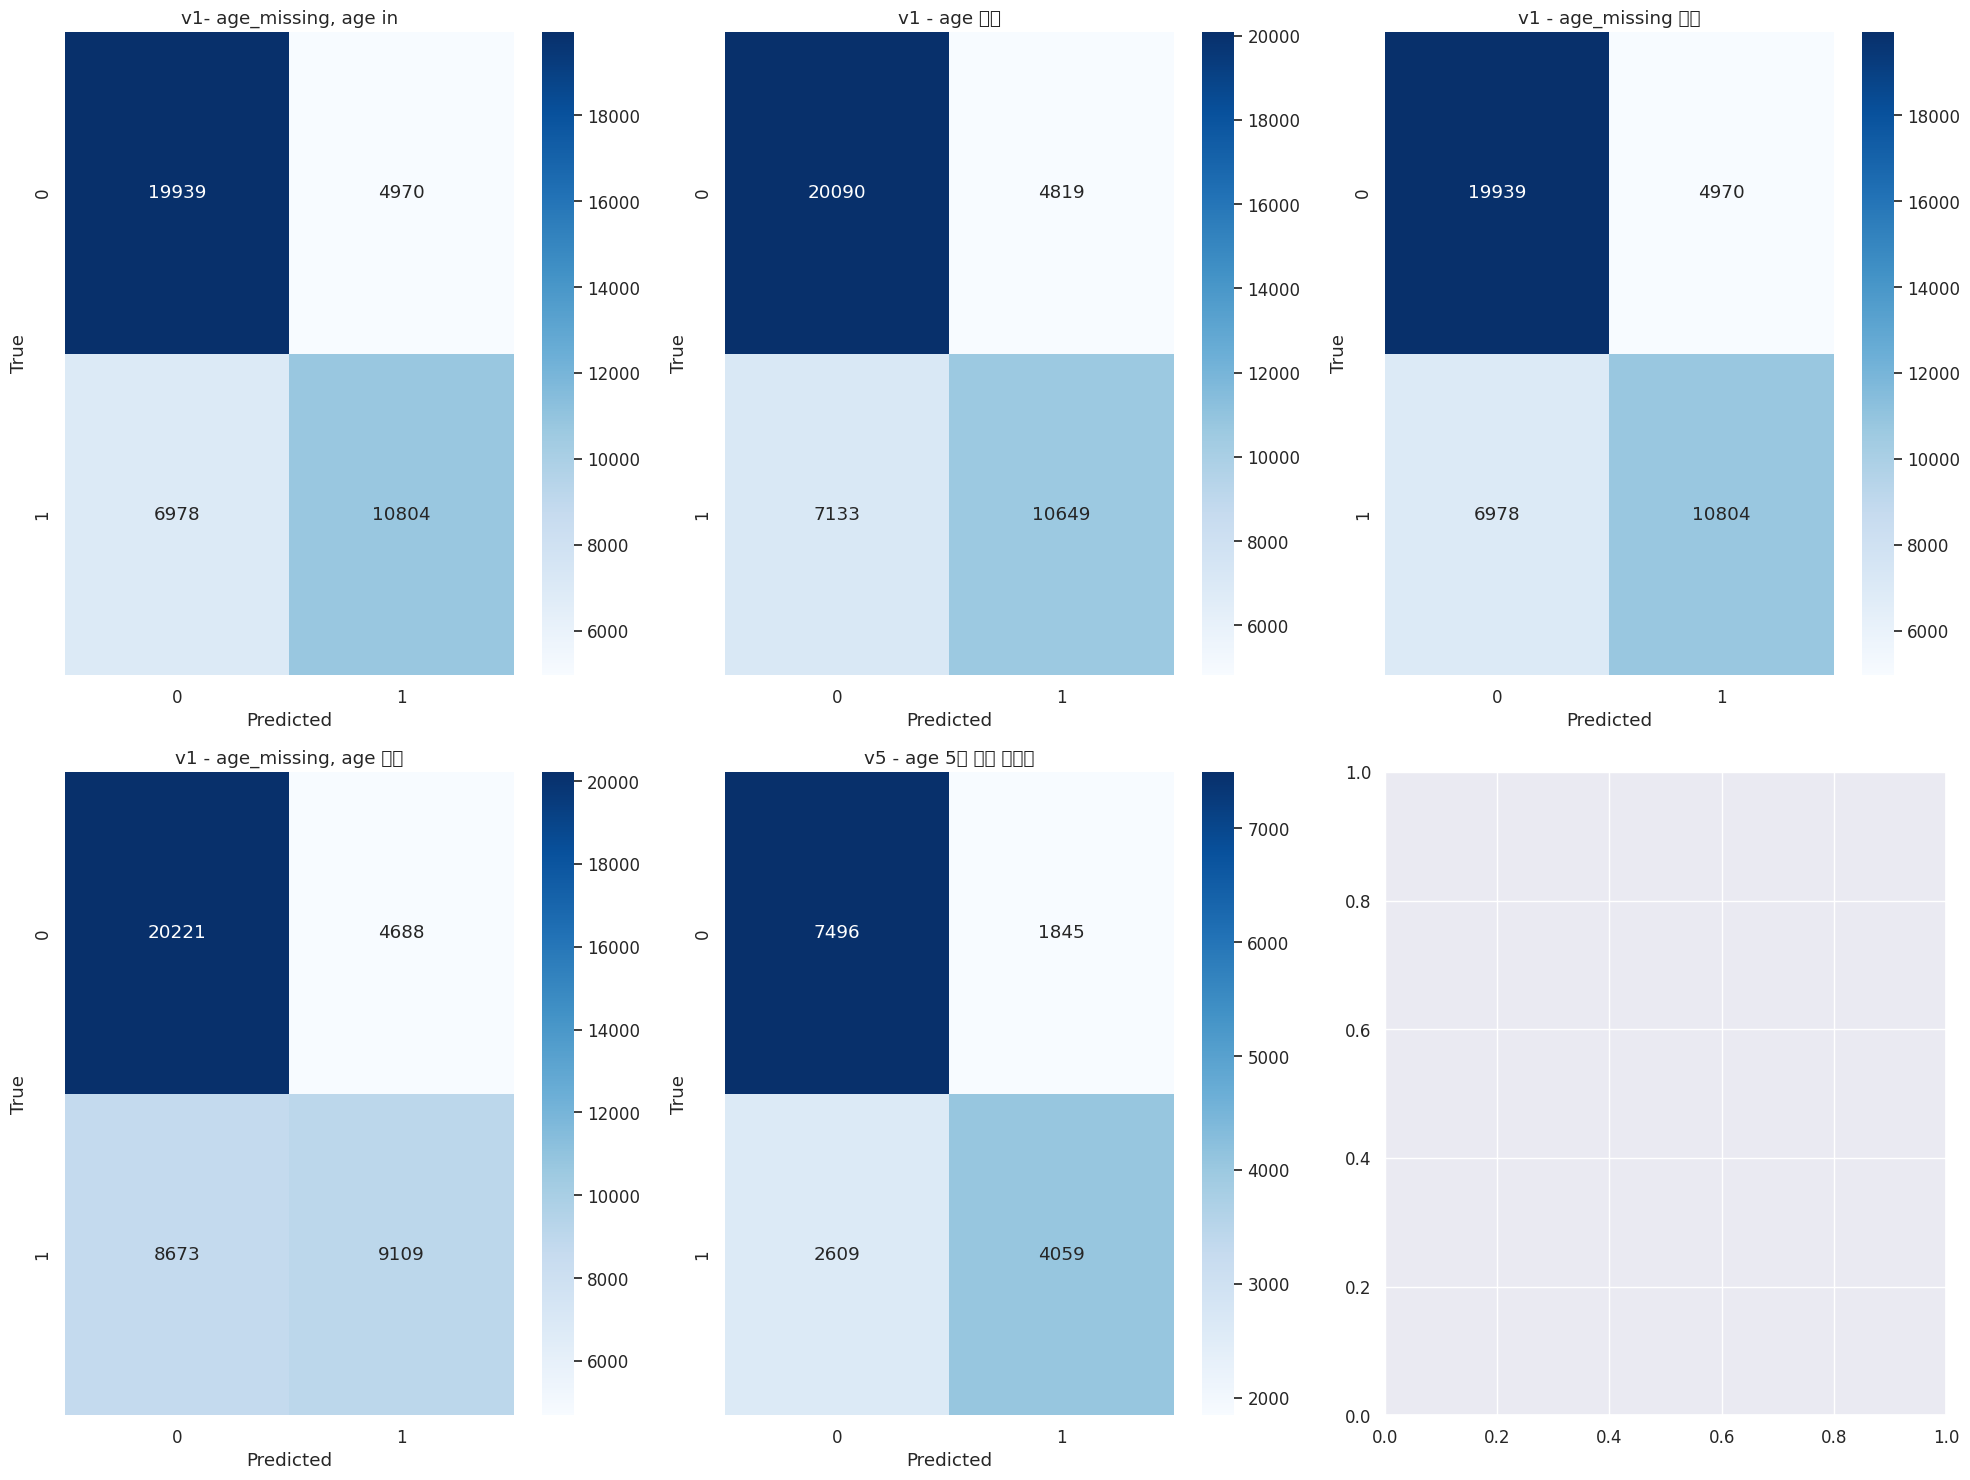

In [ ]:
import warnings
warnings.filterwarnings("ignore")  # 모든 경고 숨김

# 혼동행렬

fig, axes = plt.subplots(2, 3, figsize=(20, 15))
sns.set(font_scale=1.1)

cms = [
    (cm_v1, "v1- age_missing, age in"),
    (cm_v2, "v1 - age 제외"),
    (cm_v3, "v1 - age_missing 제외"),
    (cm_v4, "v1 - age_missing, age 제외"),
    (cm_v5, "v5 - age 5살 단위 구간화"),
]

for ax, (cm, title) in zip(axes.ravel(), cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[0, 1],
        yticklabels=[0, 1],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


# 07_Threshold 조정

In [ ]:
# threshold 조정 대상 선택
model_name_target = "v1" # v1 설정
y_valid_target = y_th_v1
y_prob_target = y_prob_th_v1

# 0.10, 0.15, ..., 0.90까지 여러 임계값을 순차적으로 시험
threshold_rows = []
for th in np.arange(0.10, 0.91, 0.05):
    y_pred_th = (y_prob_target >= th).astype(int)
    report_th = classification_report(
        y_valid_target,
        y_pred_th,
        output_dict=True,
        zero_division=0
    )
    cm_th = confusion_matrix(y_valid_target, y_pred_th)
    threshold_rows.append({
        'threshold': round(th, 2),
        'accuracy': round(report_th['accuracy'], 4),
        'precision_1': round(report_th['1']['precision'], 4),
        'recall_1': round(report_th['1']['recall'], 4),
        'f1_1': round(report_th['1']['f1-score'], 4),
        'precision_0': round(report_th['0']['precision'], 4),
        'recall_0': round(report_th['0']['recall'], 4),
        'f1_0': round(report_th['0']['f1-score'], 4),
        'tn': cm_th[0, 0],
        'fp': cm_th[0, 1],
        'fn': cm_th[1, 0],
        'tp': cm_th[1, 1]
    })

threshold_result = pd.DataFrame(threshold_rows)
print(f"[{model_name_target}] threshold별 성능표")
display(threshold_result)
print(f"[{model_name_target}] 클래스 1 recall 높은 순")
display(threshold_result.sort_values(by=['recall_1', 'f1_1'],
ascending=False).head(10))
print(f"[{model_name_target}] 클래스 1 f1-score 높은 순")
display(threshold_result.sort_values(by=['f1_1', 'recall_1'],
ascending=False).head(10))

[v1] threshold별 성능표


,threshold,accuracy,precision_1,recall_1,f1_1,precision_0,recall_0,f1_0,tn,fp,fn,tp
0,0.10,0.4853,0.4469,0.9919,0.6162,0.9553,0.1236,0.2190,1155,8186,54,6614
1,0.15,0.5361,0.4725,0.9750,0.6365,0.9257,0.2229,0.3593,2082,7259,167,6501
2,0.20,0.5785,0.4969,0.9471,0.6518,0.8930,0.3154,0.4661,2946,6395,353,6315
3,0.25,0.6434,0.5445,0.8794,0.6726,0.8466,0.4749,0.6085,4436,4905,804,5864
4,0.30,0.6766,0.5778,0.8302,0.6814,0.8239,0.5670,0.6717,5296,4045,1132,5536
5,0.35,0.6935,0.5999,0.7927,0.6830,0.8080,0.6226,0.7033,5816,3525,1382,5286
6,0.40,0.7085,0.6261,0.7449,0.6804,0.7894,0.6825,0.7320,6375,2966,1701,4967
7,0.45,0.7176,0.6548,0.6810,0.6676,0.7656,0.7437,0.7545,6947,2394,2127,4541
8,0.50,0.7159,0.6790,0.6030,0.6388,0.7376,0.7965,0.7659,7440,1901,2647,4021
9,0.55,0.7137,0.6999,0.5474,0.6143,0.7204,0.8325,0.7724,7776,1565,3018,3650


[v1] 클래스 1 recall 높은 순


,threshold,accuracy,precision_1,recall_1,f1_1,precision_0,recall_0,f1_0,tn,fp,fn,tp
0,0.10,0.4853,0.4469,0.9919,0.6162,0.9553,0.1236,0.2190,1155,8186,54,6614
1,0.15,0.5361,0.4725,0.9750,0.6365,0.9257,0.2229,0.3593,2082,7259,167,6501
2,0.20,0.5785,0.4969,0.9471,0.6518,0.8930,0.3154,0.4661,2946,6395,353,6315
3,0.25,0.6434,0.5445,0.8794,0.6726,0.8466,0.4749,0.6085,4436,4905,804,5864
4,0.30,0.6766,0.5778,0.8302,0.6814,0.8239,0.5670,0.6717,5296,4045,1132,5536
5,0.35,0.6935,0.5999,0.7927,0.6830,0.8080,0.6226,0.7033,5816,3525,1382,5286
6,0.40,0.7085,0.6261,0.7449,0.6804,0.7894,0.6825,0.7320,6375,2966,1701,4967
7,0.45,0.7176,0.6548,0.6810,0.6676,0.7656,0.7437,0.7545,6947,2394,2127,4541
8,0.50,0.7159,0.6790,0.6030,0.6388,0.7376,0.7965,0.7659,7440,1901,2647,4021
9,0.55,0.7137,0.6999,0.5474,0.6143,0.7204,0.8325,0.7724,7776,1565,3018,3650


[v1] 클래스 1 f1-score 높은 순


,threshold,accuracy,precision_1,recall_1,f1_1,precision_0,recall_0,f1_0,tn,fp,fn,tp
5,0.35,0.6935,0.5999,0.7927,0.6830,0.8080,0.6226,0.7033,5816,3525,1382,5286
4,0.30,0.6766,0.5778,0.8302,0.6814,0.8239,0.5670,0.6717,5296,4045,1132,5536
6,0.40,0.7085,0.6261,0.7449,0.6804,0.7894,0.6825,0.7320,6375,2966,1701,4967
3,0.25,0.6434,0.5445,0.8794,0.6726,0.8466,0.4749,0.6085,4436,4905,804,5864
7,0.45,0.7176,0.6548,0.6810,0.6676,0.7656,0.7437,0.7545,6947,2394,2127,4541
2,0.20,0.5785,0.4969,0.9471,0.6518,0.8930,0.3154,0.4661,2946,6395,353,6315
8,0.50,0.7159,0.6790,0.6030,0.6388,0.7376,0.7965,0.7659,7440,1901,2647,4021
1,0.15,0.5361,0.4725,0.9750,0.6365,0.9257,0.2229,0.3593,2082,7259,167,6501
0,0.10,0.4853,0.4469,0.9919,0.6162,0.9553,0.1236,0.2190,1155,8186,54,6614
9,0.55,0.7137,0.6999,0.5474,0.6143,0.7204,0.8325,0.7724,7776,1565,3018,3650


In [ ]:
# 전체 거칠게 보고, 대략 0.30~0.35가 후보, 추가 탐색
fine_thresholds = np.arange(0.30, 0.35 + 0.01, 0.01)
threshold_rows_fine = []

for th in fine_thresholds:
    y_pred_th = (y_prob_target >= th).astype(int)
    report_th = classification_report(
        y_valid_target,
        y_pred_th,
        output_dict=True,
        zero_division=0
    )

    cm_th = confusion_matrix(y_valid_target, y_pred_th)
    threshold_rows_fine.append({
        'threshold': round(th, 3),
        'accuracy': round(report_th['accuracy'], 4),
        'precision_1': round(report_th['1']['precision'], 4),
        'recall_1': round(report_th['1']['recall'], 4),
        'f1_1': round(report_th['1']['f1-score'], 4),
        'precision_0': round(report_th['0']['precision'], 4),
        'recall_0': round(report_th['0']['recall'], 4),
        'f1_0': round(report_th['0']['f1-score'], 4),
        'tn': cm_th[0, 0],
        'fp': cm_th[0, 1],
        'fn': cm_th[1, 0],
        'tp': cm_th[1, 1]
    })

threshold_result_fine = pd.DataFrame(threshold_rows_fine)
display(threshold_result_fine.sort_values(by=['f1_1', 'recall_1'],
ascending=False).head(10))

,threshold,accuracy,precision_1,recall_1,f1_1,precision_0,recall_0,f1_0,tn,fp,fn,tp
4,0.34,0.6907,0.5954,0.8032,0.6839,0.8129,0.6104,0.6973,5702,3639,1312,5356
3,0.33,0.6873,0.5907,0.8116,0.6838,0.8166,0.5985,0.6908,5591,3750,1256,5412
2,0.32,0.6834,0.5857,0.8197,0.6833,0.8200,0.5861,0.6836,5475,3866,1202,5466
5,0.35,0.6935,0.5999,0.7927,0.6830,0.8080,0.6226,0.7033,5816,3525,1382,5286
1,0.31,0.6796,0.5813,0.8248,0.6820,0.8216,0.5758,0.6771,5379,3962,1168,5500
0,0.30,0.6766,0.5778,0.8302,0.6814,0.8239,0.5670,0.6717,5296,4045,1132,5536


In [ ]:
# f1_1 높은 threshold부터, 동률이면 recall_1이 높은 것부터 순서대
candidates = threshold_result_fine[threshold_result_fine['recall_1'] >= 0.80]
best_row = candidates.sort_values(by='f1_1', ascending=False).iloc[0]
selected_threshold = best_row['threshold']

print(candidates)
print(best_row)
print("selected_threshold--->",selected_threshold)

# 0.30 → recall 최고지만 fp 많고 precision_1 가장 낮음.
# 0.34 → f1_1 최고, recall_1 0.8 이상
# 0.35 → recall은 약간 더 떨어지는 대신, fp 측면에서 조금 더 보수적

   threshold  accuracy  precision_1  recall_1    f1_1  precision_0  recall_0  \
0       0.30    0.6766       0.5778    0.8302  0.6814       0.8239    0.5670   
1       0.31    0.6796       0.5813    0.8248  0.6820       0.8216    0.5758   
2       0.32    0.6834       0.5857    0.8197  0.6833       0.8200    0.5861   
3       0.33    0.6873       0.5907    0.8116  0.6838       0.8166    0.5985   
4       0.34    0.6907       0.5954    0.8032  0.6839       0.8129    0.6104   

     f1_0    tn    fp    fn    tp  
0  0.6717  5296  4045  1132  5536  
1  0.6771  5379  3962  1168  5500  
2  0.6836  5475  3866  1202  5466  
3  0.6908  5591  3750  1256  5412  
4  0.6973  5702  3639  1312  5356  
threshold         0.3400
accuracy          0.6907
precision_1       0.5954
recall_1          0.8032
f1_1              0.6839
precision_0       0.8129
recall_0          0.6104
f1_0              0.6973
tn             5702.0000
fp             3639.0000
fn             1312.0000
tp             5356.0000
Nam

모델: v1
선택 threshold: 0.34
ROC-AUC (test): 0.7858

              precision    recall  f1-score   support

           0       0.81      0.61      0.70      9341
           1       0.60      0.80      0.68      6668

    accuracy                           0.69     16009
   macro avg       0.70      0.71      0.69     16009
weighted avg       0.72      0.69      0.69     16009

혼동행렬:
[[5731 3610]
 [1320 5348]]


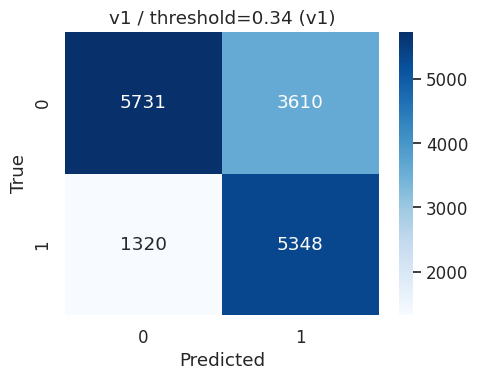

In [ ]:
# threshold는 threshold 전용 검증셋(X_th_v1)에서 고르고,
# 최종 성능은 완전히 분리된 test 셋(X_test_v1)에서 확인

y_pred_selected_v1 = (y_prob_test_v1 >= selected_threshold).astype(int)
roc_auc_selected_v1 = roc_auc_score(y_test_v1, y_prob_test_v1)

report_selected_v1 = classification_report(
    y_test_v1,
    y_pred_selected_v1,
    output_dict=True,
    zero_division=0
)

cm_selected_v1 = confusion_matrix(y_test_v1, y_pred_selected_v1)

print(f"모델: {model_name_target}")
print(f"선택 threshold: {selected_threshold:.2f}")
print(f"ROC-AUC (test): {roc_auc_selected_v1:.4f}")
print()
print(classification_report(y_test_v1, y_pred_selected_v1, zero_division=0))
print("혼동행렬:")
print(cm_selected_v1)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_selected_v1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1],
    yticklabels=[0, 1]
)
plt.title(f"{model_name_target} / threshold={selected_threshold:.2f} (v1)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 혼동행렬 비교 (baseline-selected (th 0.34))

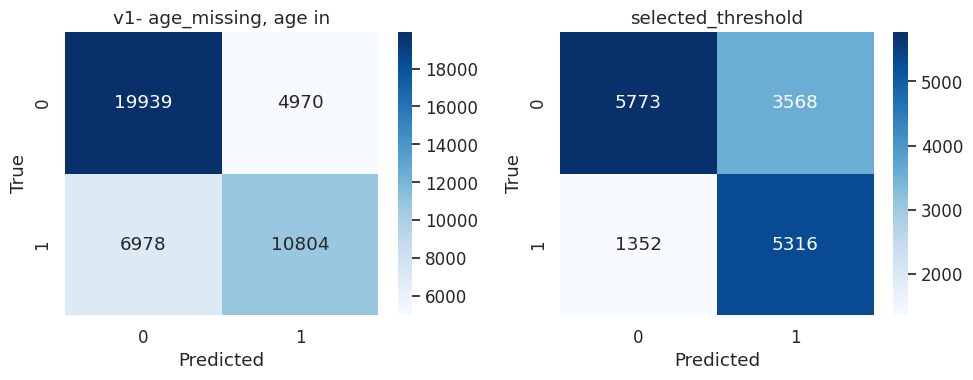

In [ ]:
# 혼동행렬 비교표 (baseline-selected (th 0.34))
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.1)

cms = [
    (cm_v1, "v1- age_missing, age in"),
    (cm_selected, "selected_threshold")
]

# cms 길이에 맞춰 1행 2열 서브플롯 생성
fig, axes = plt.subplots(1, len(cms), figsize=(10, 4))

# 혼동행렬이 1개인 경우를 대비해 axes를 리스트처럼 처리
if len(cms) == 1:
    axes = [axes]

for ax, (cm, title) in zip(axes, cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[0, 1],
        yticklabels=[0, 1],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


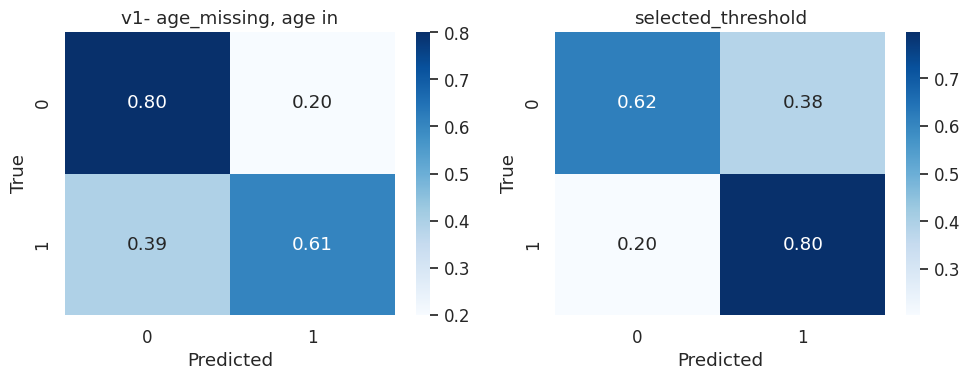

In [ ]:
# 행(실제 라벨) 기준 정규화: 각 행의 합으로 나눠 비율로 만듦
def normalize_cm(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    return cm / row_sums  # 0~1 비율

cms = [
    (cm_v1, "v1- age_missing, age in"),
    (cm_selected, "selected_threshold")
]

fig, axes = plt.subplots(1, len(cms), figsize=(10, 4))

if len(cms) == 1:
    axes = [axes]

for ax, (cm, title) in zip(axes, cms):
    cm_norm = normalize_cm(cm) # %로 보고 싶으면 100 곱해서 퍼센트
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",          # 소수점 1자리까지 비율 표시
        cmap="Blues",
        xticklabels=[0, 1],
        yticklabels=[0, 1],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


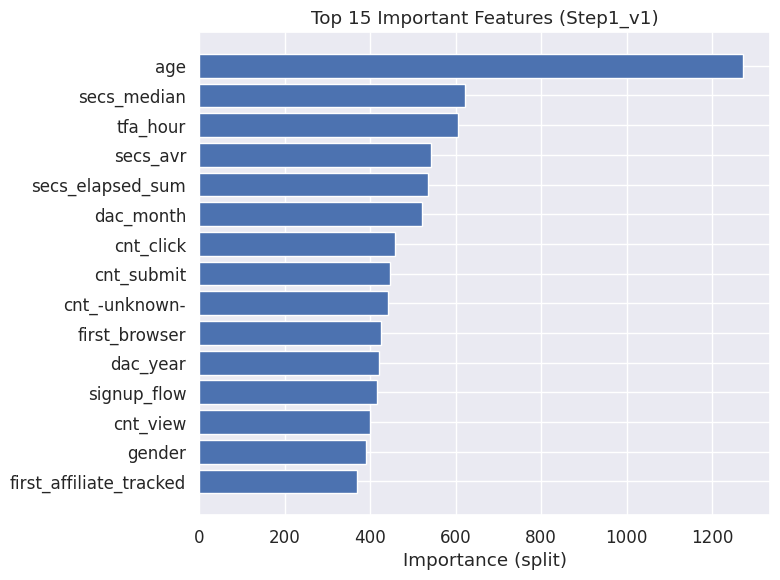

In [ ]:
# Feature Importance 시각화
import pandas as pd
import matplotlib.pyplot as plt

# 중요도 DataFrame 생성
importance_df_v1 = pd.DataFrame({
    "feature": model_step1_v1.feature_name_,
    "importance": model_step1_v1.feature_importances_
}).sort_values("importance", ascending=False)

# Top 15만 그리기
top_n = 15
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df_v1["feature"][:top_n],
    importance_df_v1["importance"][:top_n]
)
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Important Features (Step1_v1)")
plt.xlabel("Importance (split)")
plt.tight_layout()
plt.show()
